In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Step 1 — Load Cleaned Data

In [2]:
df = pd.read_csv("./data/processed/cleaned.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (99992, 61)


,document_id,LDL / HDL RATIO,Glucose Fasting,SGPT (ALT),Albumin,A/G Ratio,CALCIUM,ASPARTATE AMINOTRANSFERASE (SGOT ),Bilirubin Direct,Bilirubin Indirect,...,Non HDL Cholesterol,HbA1c,Neutrophils,25-OH VITAMIN D (TOTAL),ALKALINE PHOSPHATASE,Hemoglobin,TC/ HDL CHOLESTEROL RATIO,age,gender,gender_enc
0,0000dc1043b556f847b88a34a1875b26,-0.227515,1.490423,-0.021405,1.080124,-0.302007,1.187458,1.487870,-0.713271,0.523028,...,0.088802,0.544241,0.803404,-0.156828,2.139678,-1.170895,-0.378538,-0.187296,female,0
1,000219ef567ad65827350691e2776022,-0.468002,-0.507189,-0.628534,0.405448,1.116537,0.918617,-0.787552,0.932661,-0.184341,...,0.290877,-0.115390,-1.114647,-0.384525,-0.214119,0.370137,-0.709807,-0.791139,male,1
2,00035a9874991a7860f448275b54f05d,-0.101545,-0.286110,-0.481441,-1.495912,1.228527,-0.022326,-0.020501,0.351744,-0.558830,...,-0.045914,-0.261975,-0.016967,-0.156828,-1.016984,-0.798922,-0.115221,-1.462076,female,0


In [3]:
# Separate features from metadata
meta_cols = ["document_id", "gender"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].copy()

# Drop any remaining NaN rows (safety check)
before = len(X)
X = X.dropna()
df = df.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
print(f"Dropped {before - len(X)} rows with NaN. Using {len(X):,} patients.")

Dropped 0 rows with NaN. Using 99,992 patients.


## Step 2 — PCA (Dimensionality Reduction)
With 58+ features, clustering directly is noisy and slow.  
PCA compresses the features into fewer dimensions while keeping most of the variance.  
We use this both for speeding up tSNE and understanding which features matter most.

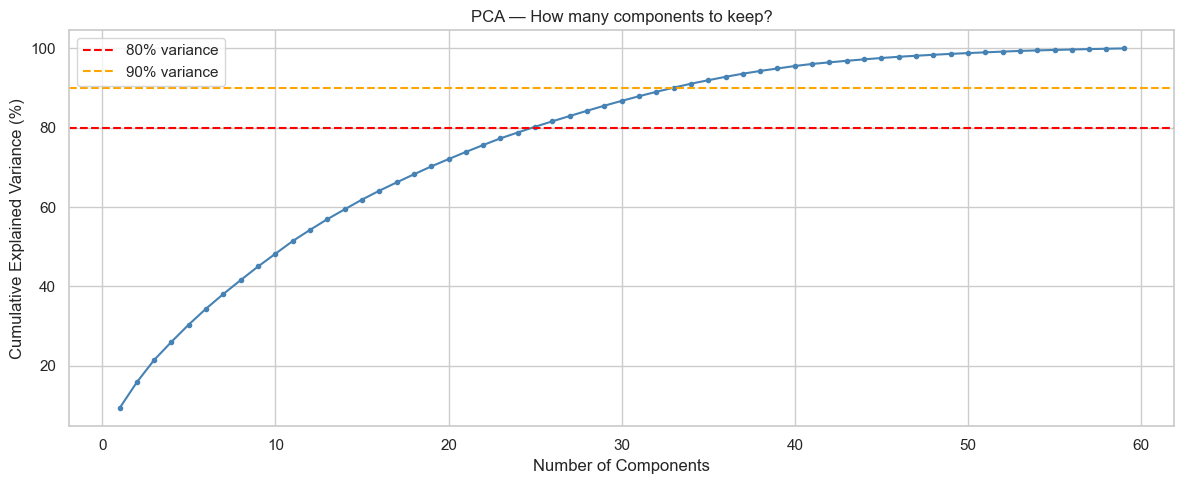

Components for 80% variance: 25
Components for 90% variance: 33


In [4]:
pca = PCA(random_state=42)
pca.fit(X)

# Cumulative explained variance plot
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure()
plt.plot(range(1, len(cumvar)+1), cumvar, marker="o", markersize=3, color="steelblue")
plt.axhline(80, color="red", linestyle="--", label="80% variance")
plt.axhline(90, color="orange", linestyle="--", label="90% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA — How many components to keep?")
plt.legend()
plt.tight_layout()
plt.show()

# Find minimum components for 80% and 90%
n_80 = np.searchsorted(cumvar, 80) + 1
n_90 = np.searchsorted(cumvar, 90) + 1
print(f"Components for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")

In [5]:
# Reduce to components explaining 80% variance
N_COMPONENTS = n_80

pca_final = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca_final.fit_transform(X)

print(f"Reduced shape: {X_pca.shape}")
print(f"Variance explained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")

Reduced shape: (99992, 25)
Variance explained: 80.2%


C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_9380\1070756189.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(loadings.index, rotation=45, ha="right", fontsize=8)
C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_9380\1070756189.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(loadings.index, rotation=45, ha="right", fontsize=8)


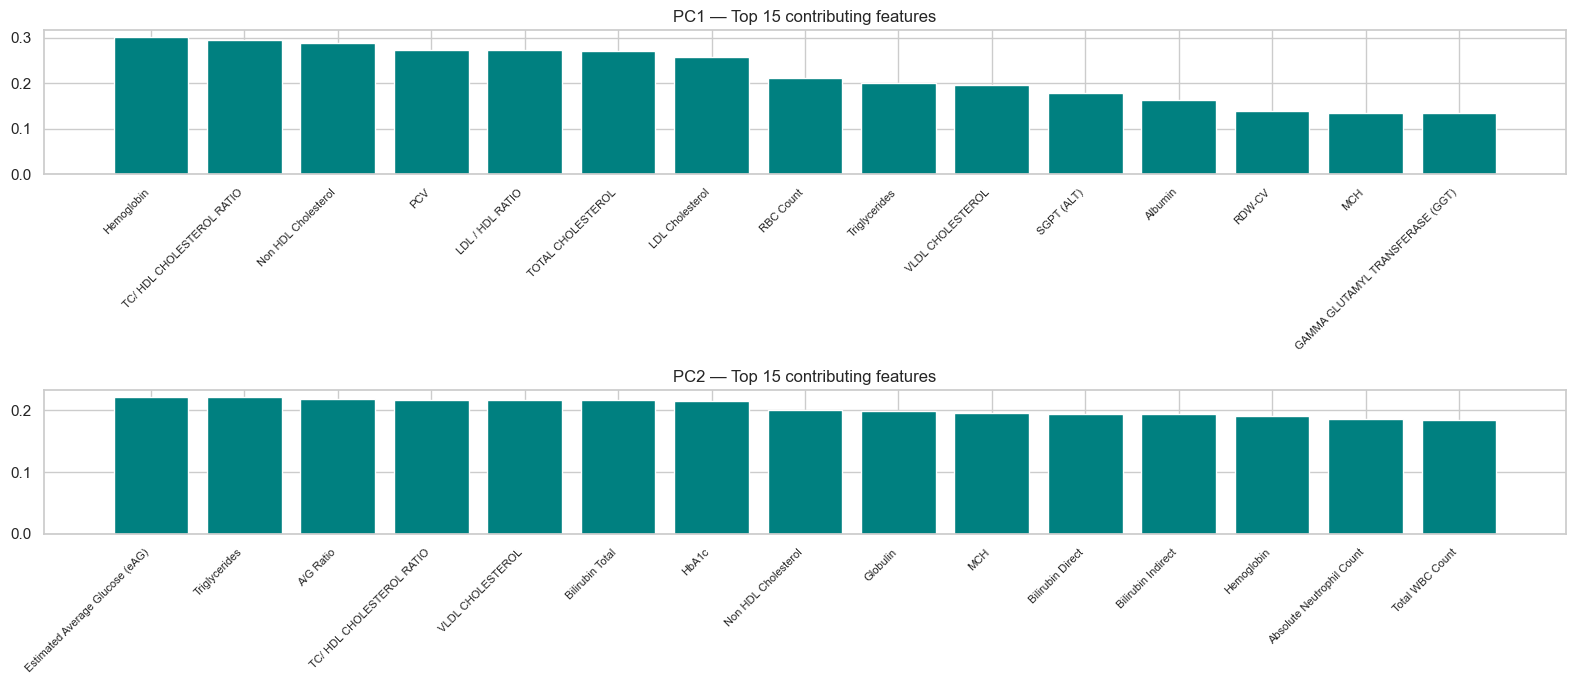

In [6]:
# Which original features contribute most to PC1 and PC2?
components_df = pd.DataFrame(
    pca_final.components_[:2],
    columns=feature_cols,
    index=["PC1", "PC2"]
)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))
for i, pc in enumerate(["PC1", "PC2"]):
    loadings = components_df.loc[pc].abs().sort_values(ascending=False).head(15)
    axes[i].bar(loadings.index, loadings.values, color="teal", edgecolor="white")
    axes[i].set_title(f"{pc} — Top 15 contributing features")
    axes[i].set_xticklabels(loadings.index, rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## Step 3 — Find Optimal Number of Clusters (K)
Two methods:
- **Elbow method**: Plot inertia (within-cluster sum of squares) vs K. The "elbow" is the best K.
- **Silhouette score**: Measures how well-separated clusters are. Higher is better (range: -1 to 1).

In [7]:
# Subsample for speed — elbow test on 20k patients is representative
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=20000, replace=False)
X_sample = X_pca[sample_idx]

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels, sample_size=5000))
    print(f"  k={k}  inertia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}")

  k=2  inertia=864516  silhouette=0.0728
  k=3  inertia=831816  silhouette=0.0476
  k=4  inertia=806946  silhouette=0.0417
  k=5  inertia=784893  silhouette=0.0498
  k=6  inertia=765508  silhouette=0.0470
  k=7  inertia=748348  silhouette=0.0459
  k=8  inertia=734065  silhouette=0.0403
  k=9  inertia=722096  silhouette=0.0389
  k=10  inertia=709040  silhouette=0.0364


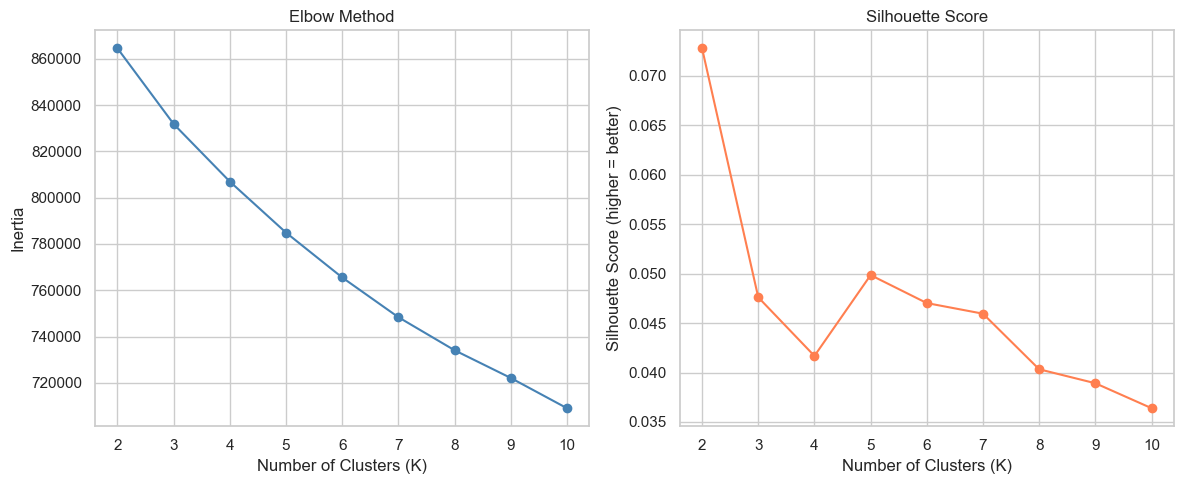

In [8]:
fig, axes = plt.subplots(1, 2)

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="coral")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score (higher = better)")

plt.tight_layout()
plt.show()

## Step 4 — Apply K-Means with Chosen K
Look at the elbow and silhouette plots above, then set `BEST_K` below.  
**General guidance:** Pick the K where inertia stops dropping sharply AND silhouette is highest.

In [9]:
# ← SET THIS based on the plots above
BEST_K = 3

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_pca)

print(f"Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    34988
1    26150
2    38854
Name: count, dtype: int64


In [10]:
# Evaluation metrics for final model
sil = silhouette_score(X_pca, df["cluster"], sample_size=10000, random_state=42)
db  = davies_bouldin_score(X_pca[:10000], df["cluster"][:10000])

print(f"Silhouette Score     : {sil:.4f}  (closer to 1.0 = better)")
print(f"Davies-Bouldin Index : {db:.4f}  (closer to 0.0 = better)")

Silhouette Score     : 0.0483  (closer to 1.0 = better)
Davies-Bouldin Index : 3.3941  (closer to 0.0 = better)


## Step 5 — tSNE Visualization
tSNE reduces high-dimensional data to 2D so we can **see** the clusters.  
It's run on a 10k subsample — running on 100k takes too long and the visual looks the same.

In [11]:
# Subsample 10k for tSNE
np.random.seed(42)
tsne_idx = np.random.choice(len(X_pca), size=10000, replace=False)
X_tsne_input = X_pca[tsne_idx]
labels_tsne = df["cluster"].values[tsne_idx]

print("Running tSNE... (takes ~2-5 minutes)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)
print("Done.")

Running tSNE... (takes ~2-5 minutes)
Done.


C:\Users\Sreeansh Dash\AppData\Local\Temp\ipykernel_9380\3636494646.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


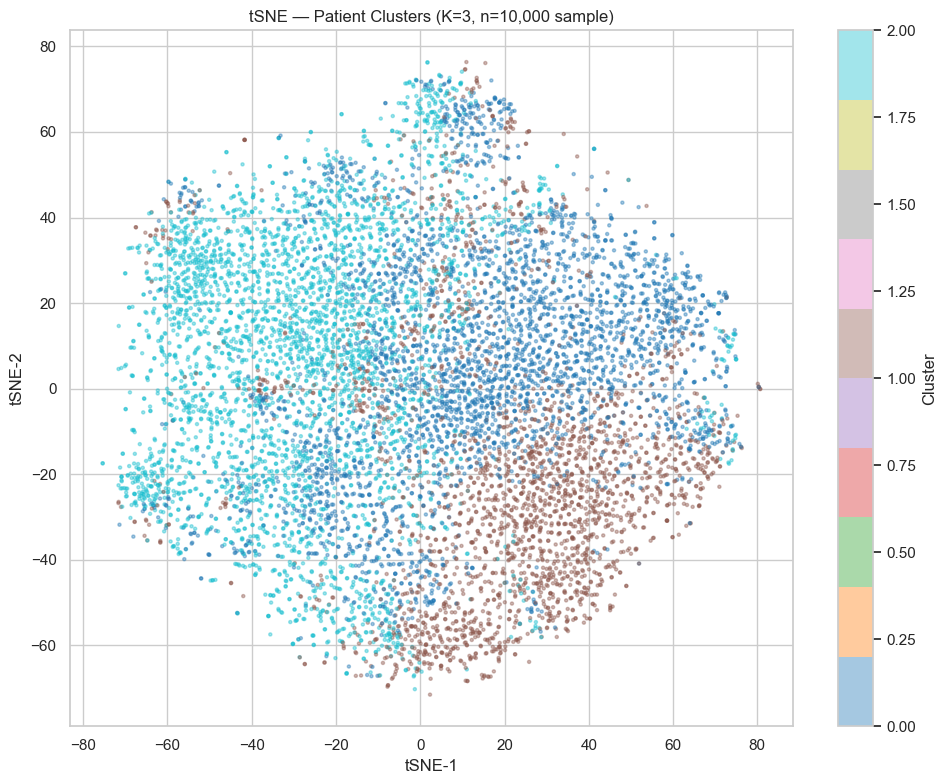

In [12]:
# Plot coloured by cluster
import os
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap
os.makedirs("./results/plots", exist_ok=True)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_tsne,
    cmap="tab10",
    alpha=0.4,
    s=5
)
cmap = plt.cm.get_cmap("tab10", 3)
plt.colorbar(scatter, label="Cluster")
plt.title(f"tSNE — Patient Clusters (K={BEST_K}, n=10,000 sample)")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.tight_layout()
plt.savefig("./results/plots/tsne_clusters.png", dpi=150)
plt.show()

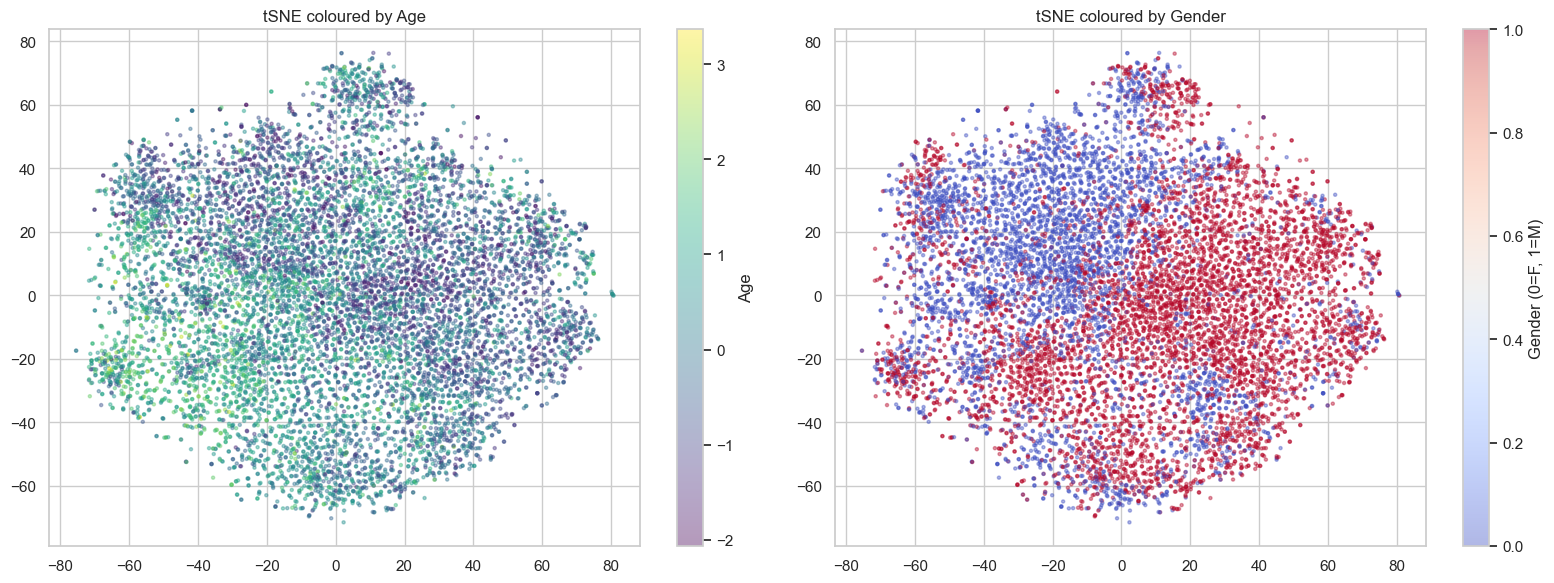

In [13]:
import os
os.makedirs("./results/plots", exist_ok=True)

# Also colour by age and gender to see if clusters align with demographics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_sample = df["age"].values[tsne_idx]
gender_sample = df["gender_enc"].values[tsne_idx]

sc1 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=age_sample, cmap="viridis", alpha=0.4, s=5)
plt.colorbar(sc1, ax=axes[0], label="Age")
axes[0].set_title("tSNE coloured by Age")

sc2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=gender_sample, cmap="coolwarm", alpha=0.4, s=5)
plt.colorbar(sc2, ax=axes[1], label="Gender (0=F, 1=M)")
axes[1].set_title("tSNE coloured by Gender")

plt.tight_layout()
plt.savefig("./results/plots/tsne_demographics.png", dpi=150)
plt.show()

## Step 6 — Cluster Profiling
What makes each cluster different?  
We compare the mean of each feature per cluster to understand what kind of patients are in each group.

In [14]:
# Use the un-normalized wide_format for interpretable values
wide = pd.read_csv("./data/processed/wide_format.csv")
wide = wide.loc[df.index]   # align rows
wide["cluster"] = df["cluster"].values

# Mean of each feature per cluster
profile = wide.groupby("cluster")[feature_cols].mean().T
profile.columns = [f"Cluster {c}" for c in profile.columns]
print("Cluster profiles (mean values per feature):")
profile.round(2)

Cluster profiles (mean values per feature):


,Cluster 0,Cluster 1,Cluster 2
LDL / HDL RATIO,2.32,3.33,2.13
Glucose Fasting,101.62,120.66,108.50
SGPT (ALT),31.94,36.98,22.87
Albumin,4.37,4.33,4.13
A/G Ratio,1.61,1.49,1.41
CALCIUM,9.29,9.32,9.18
ASPARTATE AMINOTRANSFERASE (SGOT ),27.78,29.38,24.16
Bilirubin Direct,0.24,0.19,0.18
Bilirubin Indirect,0.54,0.44,0.36
Bilirubin Total,0.79,0.63,0.53


In [15]:
# Demographics per cluster
demo_profile = wide.groupby("cluster").agg(
    n_patients=("document_id", "count"),
    mean_age=("age", "mean"),
    pct_male=("gender_enc", lambda x: (x == 1).mean() * 100)
).round(1)

print("Demographic profile per cluster:")
print(demo_profile)

Demographic profile per cluster:
         n_patients  mean_age  pct_male
cluster                                
0             34988      44.7      81.1
1             26150      46.3      68.8
2             38854      51.6      28.3


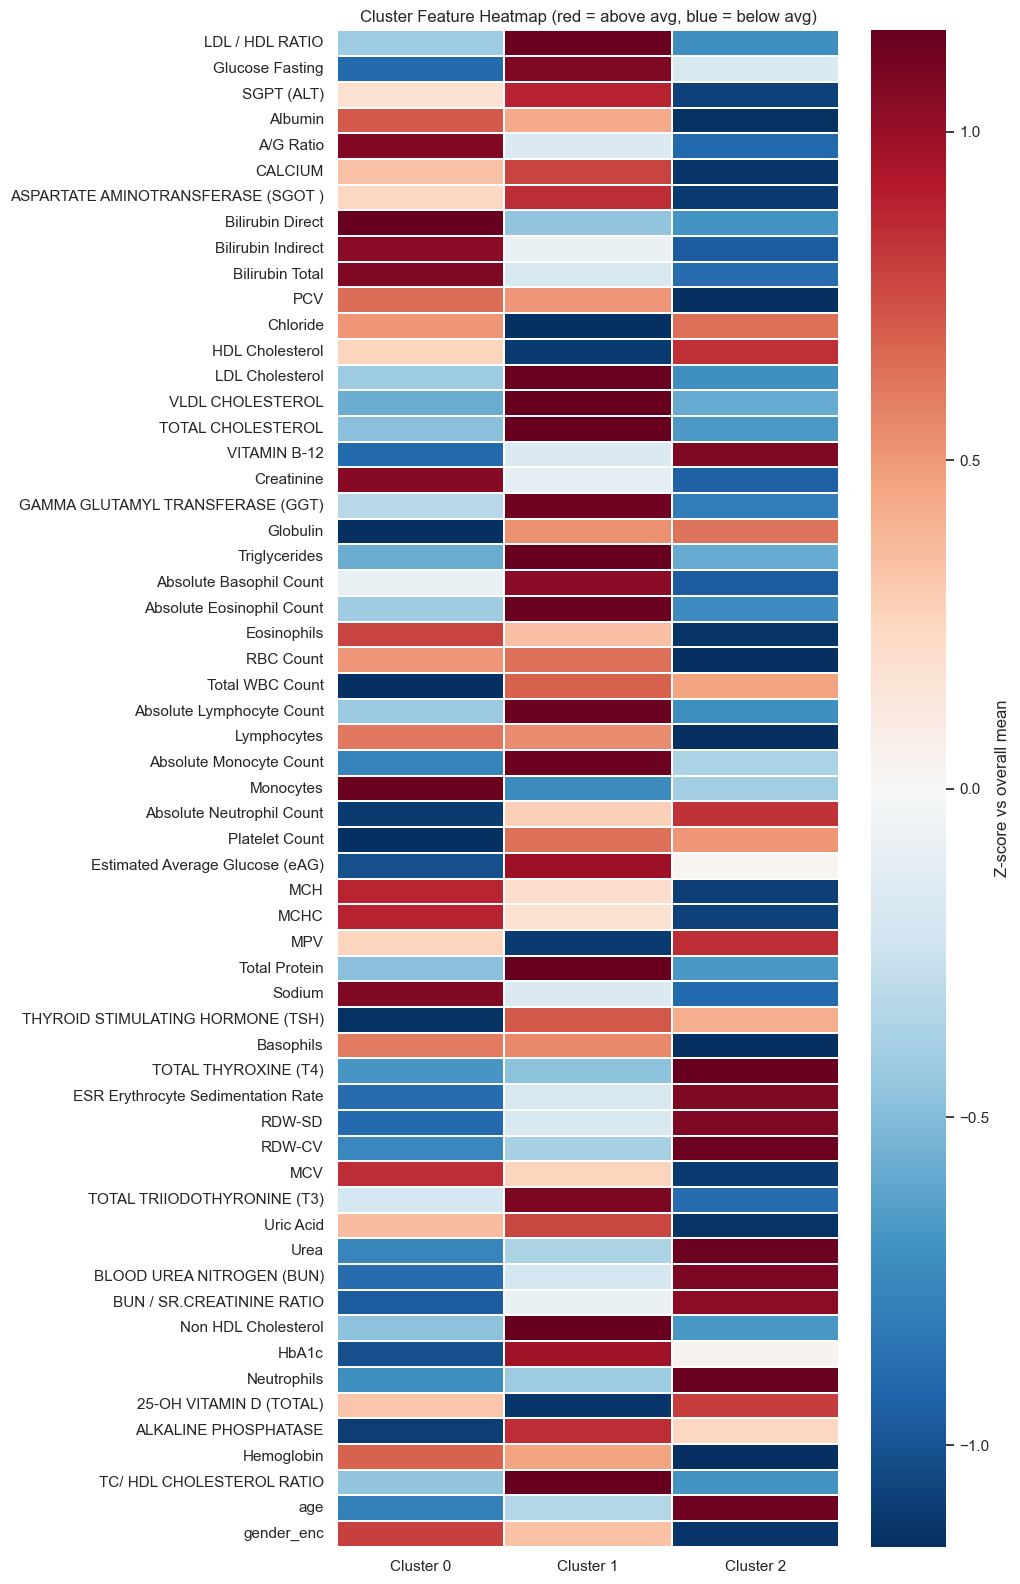

In [16]:
# Heatmap of cluster profiles (z-scored for comparison)
profile_z = (profile - profile.mean(axis=1).values.reshape(-1,1)) /              profile.std(axis=1).values.reshape(-1,1)

plt.figure(figsize=(10, 16))
sns.heatmap(profile_z, cmap="RdBu_r", center=0, linewidths=0.3,
            cbar_kws={"label": "Z-score vs overall mean"})
plt.title("Cluster Feature Heatmap (red = above avg, blue = below avg)")
plt.tight_layout()
plt.savefig("./results/plots/cluster_heatmap.png", dpi=150)
plt.show()

## Step 7 — Save Cluster Assignments

In [17]:
# Save cleaned.csv with cluster labels added
df_with_clusters = df.copy()
df_with_clusters["cluster"] = df["cluster"]
df_with_clusters.to_csv("./data/processed/cleaned_with_clusters.csv", index=False)

print(f"Saved cleaned_with_clusters.csv — shape: {df_with_clusters.shape}")
print(f"\nFinal cluster distribution:")
print(df["cluster"].value_counts().sort_index())

Saved cleaned_with_clusters.csv — shape: (99992, 62)

Final cluster distribution:
cluster
0    34988
1    26150
2    38854
Name: count, dtype: int64


## Summary
| Step | Done |
|------|------|
| PCA | Reduced ~58 features to N components (80% variance) |
| Elbow + Silhouette | Found optimal K |
| K-Means | Clustered 100k patients into K cohorts |
| tSNE | Visualized clusters in 2D |
| Profiling | Characterized each cluster by age, gender, clinical values |

**Next → `04_Classification.ipynb`**  
Per-cluster reference range computation + multi-label abnormality detection.